In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer,load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn import metrics
import numpy as np

In [11]:
data=load_breast_cancer()
X=data.data
y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [12]:
model=LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)*100
print("Breast Cancer Datset Accuracy:",accuracy)

Breast Cancer Datset Accuracy: 95.6140350877193


AttributeError: module 'matplotlib.pyplot' has no attribute 'Xlabel'

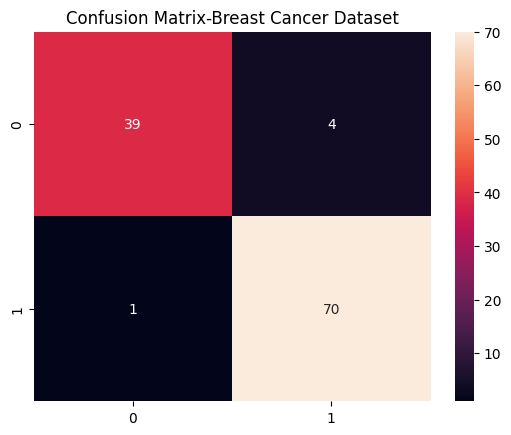

In [26]:
conf_matrix=confusion_matrix(y_test,y_pred)
plt.figure()
sns.heatmap(conf_matrix,annot=True,fmt='d')
plt.title("Confusion Matrix-Breast Cancer Dataset")
plt.Xlabel("predicted")
plt.ylabel("actual")
plt.show()

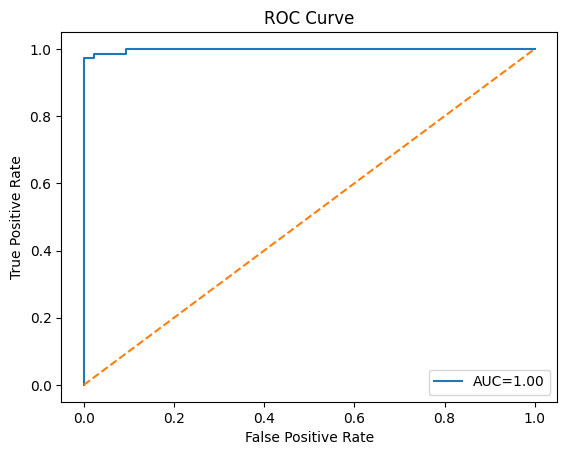

In [29]:
#ROC Curve

y_prob=model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc_score=roc_auc_score(y_test,y_prob)
plt.figure()
plt.plot(fpr,tpr,label="AUC=%.2f"%auc_score)
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

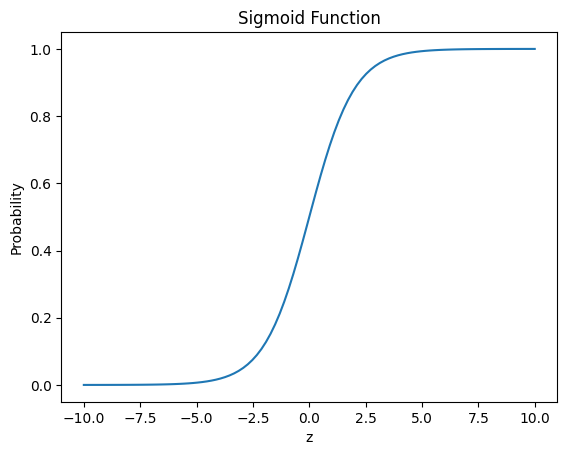

In [28]:
z=np.linspace(-10,10,100)
sigmoid=1/(1+np.exp(-z))
plt.figure()
plt.plot(z,sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Probability")
plt.show()

In [36]:
digits=load_digits()
X=digits.data
y=digits.target
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.20,random_state=42
)
reg=LogisticRegression(max_iter=1000)
reg.fit(X_train,y_train)
y_pred=reg.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_pred)*100
print("Digits Dataset Accuracy:",accuracy)

Digits Dataset Accuracy: 97.5


(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

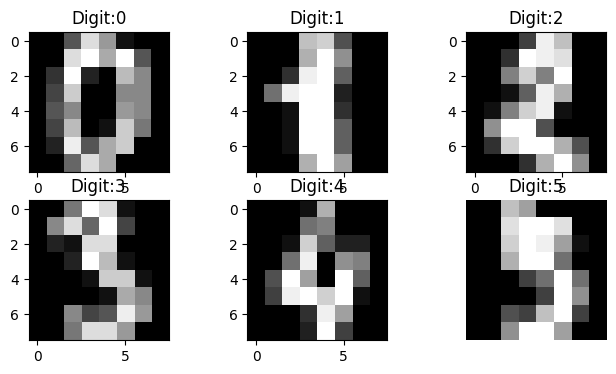

In [37]:
plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(digits.images[i],cmap="gray")
    plt.title("Digit:"+str(digits.target[i]))
plt.axis("off")